# НИРМ3 — неделя 3: архитектуры, контроль качества всего датасета и пайплайн предобработки

Продолжение `nirm3_week2_ptbxl.ipynb`.

Задачи недели 3:
1. Сравнительная таблица архитектур для анализа ЭКГ (1D-CNN, LSTM/GRU, Transformer) по литературе.
2. Прогон метрик качества недели 2 по всем 21 799 записям (на неделе 2 — подвыборка 500).
3. Пайплайн предобработки: полосовой фильтр 0.5–40 Гц, окно 0.5–9.5 с, нормировка по отведениям;
   кэш тензоров для обучения.

Все выборки — `random_state=42`, датасет — PTB-XL v1.0.3, формат — `records100`.

In [1]:
%pip install wfdb --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import ast
import glob
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import butter, sosfiltfilt, welch
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

SEED = 42
DATASET_URL = ('https://physionet.org/static/published-projects/ptb-xl/'
               'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip')

# В Colab датасет скачивается архивом; локально достаточно ptbxl_database.csv, scp_statements.csv и records100.
if not glob.glob('**/ptbxl_database.csv', recursive=True):
    !wget -q --show-progress $DATASET_URL -O ptbxl.zip
    !unzip -q ptbxl.zip -d ptbxl

DATA_PATH = os.path.dirname(glob.glob('**/ptbxl_database.csv', recursive=True)[0]) + os.sep
CACHE = 'cache' + os.sep
FIG_DIR = CACHE + 'fig' + os.sep
os.makedirs(FIG_DIR, exist_ok=True)
print('DATA_PATH =', DATA_PATH)
plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

DATA_PATH = ptbxl\


In [3]:
df = pd.read_csv(DATA_PATH + 'ptbxl_database.csv', index_col='ecg_id')
df['scp_codes'] = df.scp_codes.apply(ast.literal_eval)

scp = pd.read_csv(DATA_PATH + 'scp_statements.csv', index_col=0)
scp = scp[scp.diagnostic == 1]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']


def to_superclass(codes):
    return sorted({scp.loc[c].diagnostic_class for c in codes if c in scp.index})


df['superclass'] = df.scp_codes.apply(to_superclass)
df['sex_label'] = df.sex.map({0: 'male', 1: 'female'})
print(f'записей: {len(df)}, пациентов: {df.patient_id.nunique()}')

записей: 21799, пациентов: 18869


## Задача 1. Сравнение архитектур для анализа ЭКГ

Цель — выбрать архитектуры для недель 5–8 и задать ориентир качества. Сравнение по литературе; все
цифры — macro-AUC на задаче PTB-XL *superdiagnostic* (5 суперклассов, многометочная постановка).
Напрямую сравнимы только строки со стандартным протоколом: `strat_fold` 1–8 / 9 / 10, 100 Гц.

**Таблица A. Опубликованные результаты**

| Модель | Семейство | Источник | macro-AUC | Протокол |
|---|---|---|---|---|
| resnet1d_wang | 1D-CNN | Strodthoff et al., 2021 | 0.930 (±0.005) | стандартный |
| xresnet1d101 | 1D-CNN | Strodthoff et al., 2021 | 0.928 (±0.005) | стандартный |
| fcn_wang | 1D-CNN | Strodthoff et al., 2021 | 0.925 (±0.006) | стандартный |
| inception1d | 1D-CNN | Strodthoff et al., 2021 | 0.921 (±0.006) | стандартный |
| lstm | RNN | Strodthoff et al., 2021 | 0.927 (±0.005) | стандартный |
| lstm_bidir | RNN | Strodthoff et al., 2021 | 0.921 (±0.006) | стандартный |
| Wavelet + NN | признаки + MLP | Strodthoff et al., 2021 | 0.874 (±0.007) | стандартный |
| ансамбль моделей | смешанный | Strodthoff et al., 2021 | 0.934 (±0.005) | стандартный |
| IMLE-Net (CNN + BiLSTM + attention) | гибрид CNN-LSTM | Reddy et al., 2021 | 0.922 | стандартный |
| MSW-Transformer | Transformer | Cheng et al., 2023 (arXiv) | 0.923 | стандартный |
| HC-CNN-TN (CNN-Transformer + ручные признаки) | гибрид CNN-Transformer | Xie et al., 2025 | 0.933 | 100 Гц, обучение 1–8; тестовый фолд не указан однозначно |
| ST-MEM (ViT-B, самообучение) | Transformer | Na et al., 2024 | 0.933; без предобучения 0.905 | **несравнимо**: 250 Гц, случайное разбиение 70/10/20, мультиклассовая постановка |

**Таблица B. Сравнение семейств архитектур**

| Семейство | Что улавливает | Стоимость | Потребность в данных | Интерпретация |
|---|---|---|---|---|
| 1D-CNN | локальную морфологию комплексов (QRS, ST, T) за счёт локальных свёрток с общими весами | 0.06–1.9 млн параметров; хорошо параллелится | лучшие одиночные модели на PTB-XL (~21 тыс. записей) без предобучения | карты значимости: Grad-CAM, LRP |
| LSTM / GRU | временные зависимости вдоль записи (ритм) | 0.9–2.3 млн параметров; последовательное вычисление, медленнее CNN | на PTB-XL сопоставимы с CNN (lstm 0.927) | обычно через добавленный слой внимания |
| Transformer | дальние зависимости через self-attention | вычислительно дорогие | высокая: без предобучения переобучаются на данных масштаба PTB-XL (ST-MEM: 0.905 против 0.933 с предобучением) | карты внимания, но их трактовка спорна; рекомендуется Grad-CAM |
| Гибриды (CNN + RNN / Transformer) | CNN — локальные признаки, RNN/Transformer — контекст | умеренная | отдельно не оценивалась | многоуровневое внимание (IMLE-Net, сверено с врачом) |

**Выводы для плана:**

1. Ориентир для baseline недели 5 — `resnet1d_wang` (0.930): небольшая остаточная 1D-CNN — лучшая одиночная
   модель стандартного бенчмарка. Её и воспроизводим первой.
2. Transformer без предобучения на PTB-XL не превосходит CNN; на неделе 8 имеет смысл гибрид CNN → Transformer
   (свёрточный «стебель» + attention поверх признаков), а не «чистый» ViT.
3. Цифры разных статей сравнимы только при одинаковом протоколе: повторные запуски одной и той же сети
   другими авторами дают 0.895–0.912 против 0.928 у Strodthoff. Поэтому все модели года 2 оцениваются одним
   протоколом и на одном тестовом фолде 10.

**Источники:** Strodthoff N., Wagner P., Schaeffter T., Samek W. (2021) *IEEE JBHI* 25(5):1519–1528,
doi:10.1109/JBHI.2020.3022989; Reddy L. et al. (2021) *IEEE SMC*, doi:10.1109/SMC52423.2021.9658706;
Cheng R. et al. (2023) arXiv:2306.12098; Na Y. et al. (2024) *ICLR*, arXiv:2402.09450;
Xie T., Pal P., Chew E. (2025) *Computing in Cardiology* 52, doi:10.22489/CinC.2025.268;
Feyisa D. W. et al. (2022) *Comput. Intell. Neurosci.*, doi:10.1155/2022/8413294;
Zhao Z. (2023) arXiv:2306.01249; Wu Z., Guo C. (2025) *BioMed. Eng. OnLine* 24:23,
doi:10.1186/s12938-025-01349-w.

## Задача 2. Контроль качества всех 21 799 записей

На неделе 2 метрики качества считались по подвыборке 500 записей. Теперь — по всему датасету, теми же
функциями и порогами: дрейф изолинии (доля мощности 0.01–0.5 Гц), высокочастотный шум (30–49 Гц),
плоские участки, мёртвые отведения (размах < 0.05 мВ), пропуски (NaN).

Сначала весь `records100` читается в память одним массивом `(N, 1000, 12)` — он же вход пайплайна
предобработки в задаче 3.

In [4]:
FS = 100
N_SAMPLES, N_LEADS = 10 * FS, 12

t0 = time.perf_counter()
raw = np.empty((len(df), N_SAMPLES, N_LEADS), dtype=np.float32)
nan_frac = np.zeros(len(df))
for i, fn in enumerate(df.filename_lr):
    sig, meta = wfdb.rdsamp(DATA_PATH + fn)
    nan_frac[i] = np.isnan(sig).mean()
    raw[i] = np.nan_to_num(sig)
LEADS = meta['sig_name']
print(f'прочитано {len(raw)} записей за {time.perf_counter() - t0:.0f} с; '
      f'массив {raw.shape}, {raw.nbytes / 1024**3:.2f} ГБ; отведения: {LEADS}')

прочитано 21799 записей за 939 с; массив (21799, 1000, 12), 0.97 ГБ; отведения: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [5]:
BASELINE_BAND = (0.01, 0.5)
HF_BAND = (30.0, 49.0)
DRIFT_FLAG, HF_FLAG, FLAT_FLAG = 0.30, 0.08, 0.20
CHUNK = 2000


def band_shares(x, bands, fs=FS, nperseg=512):
    """Доля мощности каждого отведения в каждой полосе; x: (n, time, leads) -> {band: (n, leads)}."""
    out = {name: [] for name in bands}
    for s in range(0, len(x), CHUNK):
        freqs, psd = welch(x[s:s + CHUNK], fs=fs, nperseg=nperseg, axis=1)
        total = np.trapezoid(psd, freqs, axis=1)
        total[total <= 0] = np.inf
        for name, (lo, hi) in bands.items():
            m = (freqs >= lo) & (freqs <= hi)
            out[name].append(np.trapezoid(psd[:, m], freqs[m], axis=1) / total)
    return {name: np.concatenate(v) for name, v in out.items()}


def longest_constant_share(x):
    """Максимальная доля отведения, занятая константой; x: (n, time, leads) -> (n, leads)."""
    flat = np.abs(np.diff(x, axis=1)) < 1e-9
    best = np.zeros(flat.shape[0::2], dtype=int)
    run = np.zeros_like(best)
    for t in range(flat.shape[1]):
        run = np.where(flat[:, t], run + 1, 0)
        best = np.maximum(best, run)
    return (best + 1) / x.shape[1]


def quality_table(x):
    parts = []
    for s in range(0, len(x), CHUNK):
        chunk = x[s:s + CHUNK]
        shares = band_shares(chunk, {'drift': BASELINE_BAND, 'hf': HF_BAND}, nperseg=512)
        p2p = chunk.max(axis=1) - chunk.min(axis=1)
        parts.append(pd.DataFrame({
            'drift_max': shares['drift'].max(axis=1), 'hf_max': shares['hf'].max(axis=1),
            'flat_max': longest_constant_share(chunk).max(axis=1),
            'p2p_max': p2p.max(axis=1), 'p2p_min': p2p.min(axis=1)}))
    return pd.concat(parts, ignore_index=True)


t0 = time.perf_counter()
q = quality_table(raw)
q.index = df.index
q['nan_frac'] = nan_frac
q['flag_drift'] = q.drift_max > DRIFT_FLAG
q['flag_hf'] = q.hf_max > HF_FLAG
q['flag_flat'] = q.flat_max > FLAT_FLAG
q['flag_nan'] = q.nan_frac > 0
q['flag_lowamp'] = q.p2p_min < 0.05
FLAGS = ['flag_drift', 'flag_hf', 'flag_flat', 'flag_nan', 'flag_lowamp']
q['flag_any'] = q[FLAGS].any(axis=1)
print(f'метрики посчитаны за {time.perf_counter() - t0:.0f} с\n')
print(q[FLAGS + ['flag_any']].sum().to_string())
print(f'\nзаписей хотя бы с одним флагом: {q.flag_any.sum()} ({q.flag_any.mean()*100:.1f}%); '
      f'на подвыборке недели 2 было 25.2 %')

метрики посчитаны за 20 с

flag_drift     2583
flag_hf        3310
flag_flat         3
flag_nan          0
flag_lowamp       1
flag_any       5648

записей хотя бы с одним флагом: 5648 (25.9%); на подвыборке недели 2 было 25.2 %


In [6]:
# Согласие с врачебной разметкой помех на всём датасете: p-value и AUC метрики как «детектора» разметки
ann = {
    'baseline_drift': df.baseline_drift.notna(),
    'static_noise': df.static_noise.notna(),
    'burst_noise': df.burst_noise.notna(),
    'electrodes_problems': df.electrodes_problems.notna(),
}
ann_any = pd.concat(ann, axis=1).any(axis=1)
print(f'размечено врачом: ' + ', '.join(f'{k} {v.sum()}' for k, v in ann.items())
      + f'; хотя бы одна пометка — {ann_any.sum()} ({ann_any.mean()*100:.1f}%)\n')

agreement = []
for metric, label in (('drift_max', 'baseline_drift'), ('hf_max', 'static_noise'), ('hf_max', 'burst_noise')):
    y = ann[label]
    agreement.append({
        'metric': metric, 'annotation': label, 'n_annotated': int(y.sum()),
        'median_annot': round(q.loc[y, metric].median(), 4),
        'median_rest': round(q.loc[~y, metric].median(), 4),
        'p_value': mannwhitneyu(q.loc[y, metric], q.loc[~y, metric]).pvalue,
        'AUC': round(roc_auc_score(y, q[metric]), 3),
    })
agreement = pd.DataFrame(agreement)
print(agreement.to_string(index=False))

both = pd.crosstab(q.flag_any.rename('auto flag'), ann_any.rename('annotated'))
print(f'\nсовпадение автоматического флага и врачебной разметки:\n{both}')

размечено врачом: baseline_drift 1598, static_noise 3260, burst_noise 613, electrodes_problems 30; хотя бы одна пометка — 5010 (23.0%)



   metric     annotation  n_annotated  median_annot  median_rest      p_value   AUC
drift_max baseline_drift         1598        0.2929       0.0679 0.000000e+00 0.821
   hf_max   static_noise         3260        0.0452       0.0397 3.899815e-27 0.559
   hf_max    burst_noise          613        0.0423       0.0404 1.139595e-01 0.519

совпадение автоматического флага и врачебной разметки:
annotated  False  True 
auto flag              
False      12800   3351
True        3989   1659


In [7]:
# Где сосредоточены проблемные записи: по суперклассам и по полу
rows = []
for c in SUPERCLASSES:
    m = df.superclass.apply(lambda v, c=c: c in v)
    rows.append({'group': c, 'n': int(m.sum()), 'flag_any_%': round(q.loc[m, 'flag_any'].mean() * 100, 1),
                 'flag_drift_%': round(q.loc[m, 'flag_drift'].mean() * 100, 1),
                 'annotated_%': round(ann_any[m].mean() * 100, 1)})
for s in ('male', 'female'):
    m = df.sex_label == s
    rows.append({'group': s, 'n': int(m.sum()), 'flag_any_%': round(q.loc[m, 'flag_any'].mean() * 100, 1),
                 'flag_drift_%': round(q.loc[m, 'flag_drift'].mean() * 100, 1),
                 'annotated_%': round(ann_any[m].mean() * 100, 1)})
flag_by_group = pd.DataFrame(rows).set_index('group')
print(flag_by_group)

            n  flag_any_%  flag_drift_%  annotated_%
group                                               
NORM     9514        27.5          13.6         21.5
MI       5469        22.9           9.9         25.8
STTC     5235        28.5          11.7         23.6
CD       4898        19.4          11.0         23.1
HYP      2649        22.8           8.2         20.0
male    11354        22.7          10.0         23.4
female  10445        29.3          13.9         22.5


In [8]:
# Женские записи флагуются чаще при одинаковой врачебной разметке. Проверка: метрики относительные
# (доля мощности), поэтому при меньшей амплитуде ЭКГ та же абсолютная помеха даёт большую долю.
male, female = (df.sex_label == 'male').to_numpy(), (df.sex_label == 'female').to_numpy()
clean = ~ann_any.to_numpy()
p_amp = mannwhitneyu(q.p2p_max[male], q.p2p_max[female]).pvalue
print(f'максимальный размах отведения, мВ: male {q.p2p_max[male].median():.2f}, '
      f'female {q.p2p_max[female].median():.2f} (Mann-Whitney p = {p_amp:.1e})')
for name in ('flag_drift', 'flag_hf'):
    print(f'{name} среди записей без врачебной пометки: male {q[name][male & clean].mean()*100:.1f}%, '
          f'female {q[name][female & clean].mean()*100:.1f}%')
amp_tertile = pd.qcut(q.p2p_max, 3, labels=['low', 'mid', 'high'])
print('\nдоля флага дрейфа по терцилям амплитуды, %:')
print((q.groupby([amp_tertile, df.sex_label], observed=True).flag_drift.mean() * 100).unstack().round(1))

максимальный размах отведения, мВ: male 2.80, female 2.34 (Mann-Whitney p = 0.0e+00)
flag_drift среди записей без врачебной пометки: male 8.5%, female 11.7%
flag_hf среди записей без врачебной пометки: male 13.0%, female 16.2%

доля флага дрейфа по терцилям амплитуды, %:


sex_label  female  male
p2p_max                
low          11.1   7.0
mid          12.9   8.5
high         19.9  13.0


## Задача 3. Пайплайн предобработки

Решения, принятые по результатам недели 2:

- **Полосовой фильтр 0.5–40 Гц**, Баттерворт 3-го порядка, прямой и обратный проход (`sosfiltfilt`,
  нулевой фазовый сдвиг). Нижняя граница убирает дрейф изолинии; при нулевой фазе она не искажает
  ST-сегмент так, как обычный однонаправленный фильтр. Верхняя граница 40 Гц отсекает ЭМГ-шум;
  режекторный фильтр 50 Гц не нужен (неделя 2: наводки нет, p = 0.98).
- **Окно 0.5–9.5 с** (900 отсчётов): отсекаются артефакты конца записи, найденные на неделе 2.
  Фильтр применяется к полной 10-секундной записи, а обрезка — после, чтобы переходные процессы
  фильтра на краях тоже ушли.
- **Нормировка по отведениям статистикой обучающих фолдов 1–8** (а не z-score каждой записи) —
  обоснование ниже, в проверке на суперклассе HYP.

In [9]:
BAND = (0.5, 40.0)
ORDER = 3
CROP = slice(int(0.5 * FS), int(9.5 * FS))
TRAIN_FOLDS = range(1, 9)

sos = butter(ORDER, BAND, btype='bandpass', fs=FS, output='sos')


def preprocess(x):
    """(n, 1000, 12) сырые мВ -> (n, 900, 12) отфильтрованные мВ, окно 0.5-9.5 с."""
    out = np.empty((len(x), CROP.stop - CROP.start, x.shape[2]), dtype=np.float32)
    for s in range(0, len(x), CHUNK):
        out[s:s + CHUNK] = sosfiltfilt(sos, x[s:s + CHUNK], axis=1)[:, CROP]
    return out


t0 = time.perf_counter()
X = preprocess(raw)
print(f'предобработка {len(X)} записей за {time.perf_counter() - t0:.0f} с, X: {X.shape}, {X.nbytes/1024**3:.2f} ГБ')

train_mask = df.strat_fold.isin(TRAIN_FOLDS).to_numpy()
lead_mean = X[train_mask].mean(axis=(0, 1))
lead_std = X[train_mask].std(axis=(0, 1))
print(pd.DataFrame({'mean, мВ': lead_mean.round(4), 'std, мВ': lead_std.round(3)}, index=LEADS).T)

предобработка 21799 записей за 12 с, X: (21799, 900, 12), 0.88 ГБ


              I     II    III    AVR    AVL    AVF     V1     V2     V3  \
mean, мВ  0.000  0.000 -0.000 -0.000  0.000  0.000 -0.000  0.000  0.000   
std, мВ   0.142  0.145  0.142  0.125  0.122  0.125  0.201  0.314  0.305   

             V4     V5     V6  
mean, мВ -0.000  0.000  0.000  
std, мВ   0.273  0.236  0.189  


In [10]:
# Что фильтр сделал с сигналом: дрейф, ВЧ-шум и амплитуда комплекса QRS
before = band_shares(raw[:, CROP], {'drift': BASELINE_BAND, 'hf': (40.0, 49.0)}, nperseg=512)
after = band_shares(X, {'drift': BASELINE_BAND, 'hf': (40.0, 49.0)}, nperseg=512)
p2p_raw = raw[:, CROP].max(axis=1) - raw[:, CROP].min(axis=1)
p2p_flt = X.max(axis=1) - X.min(axis=1)
amp_ratio = np.median(p2p_flt / np.maximum(p2p_raw, 1e-6), axis=0)

effect = pd.DataFrame({
    'до фильтра': [np.median(before['drift'].max(1)), np.median(before['hf'].max(1)),
                   (before['drift'].max(1) > DRIFT_FLAG).mean() * 100],
    'после': [np.median(after['drift'].max(1)), np.median(after['hf'].max(1)),
              (after['drift'].max(1) > DRIFT_FLAG).mean() * 100],
}, index=['медиана доли мощности 0.01-0.5 Гц', 'медиана доли мощности 40-49 Гц', '% записей с флагом дрейфа'])
print(effect.round(4))
print(f'\nразмах отведения после/до фильтра (медиана по записям): '
      + ', '.join(f'{l} {r:.3f}' for l, r in zip(LEADS, amp_ratio)))
print(f'коэффициент корреляции до/после, медиана по отведениям: '
      f'{np.median([np.corrcoef(raw[i, CROP, j], X[i, :, j])[0, 1] for i in range(0, len(X), 50) for j in range(12)]):.3f}')

                                   до фильтра   после
медиана доли мощности 0.01-0.5 Гц      0.0738  0.0015
медиана доли мощности 40-49 Гц         0.0057  0.0005
% записей с флагом дрейфа             10.5418  0.0000

размах отведения после/до фильтра (медиана по записям): I 0.976, II 0.961, III 0.955, AVR 0.969, AVL 0.966, AVF 0.952, V1 0.979, V2 0.986, V3 0.982, V4 0.982, V5 0.979, V6 0.968


коэффициент корреляции до/после, медиана по отведениям: 0.985


### Почему не z-score каждой записи

Популярный вариант — нормировать каждую запись на её собственные среднее и СКО. Но для гипертрофии
(HYP) диагностическим признаком служит именно **амплитуда** QRS (вольтажные критерии), и
пер-записная нормировка её стирает. Проверка: насколько хорошо размах отведений V1 и V5 сам по себе
отделяет HYP от NORM — в милливольтах и после z-score каждой записи.

In [11]:
is_norm_only = df.superclass.apply(lambda v: v == ['NORM']).to_numpy()
is_hyp = df.superclass.apply(lambda v: 'HYP' in v).to_numpy()
sel = is_norm_only | is_hyp
y_hyp = is_hyp[sel]

X_sel = X[sel]
per_record = (X_sel - X_sel.mean(axis=1, keepdims=True)) / (X_sel.std(axis=1, keepdims=True) + 1e-6)
global_norm = (X_sel - lead_mean) / lead_std

amp_rows = []
for lead in ('V1', 'V5', 'AVL'):
    j = LEADS.index(lead)
    for name, arr in (('мВ (без нормировки)', X_sel), ('глобальная по фолдам 1-8', global_norm),
                      ('z-score каждой записи', per_record)):
        p2p = arr[:, :, j].max(axis=1) - arr[:, :, j].min(axis=1)
        amp_rows.append({'lead': lead, 'normalization': name, 'AUC HYP vs NORM': roc_auc_score(y_hyp, p2p)})
amp_auc = pd.DataFrame(amp_rows).pivot(index='normalization', columns='lead', values='AUC HYP vs NORM')
print(f'HYP: {y_hyp.sum()}, NORM (без других диагнозов): {(~y_hyp).sum()}')
print(amp_auc.round(3))
del X_sel, per_record, global_norm

HYP: 2649, NORM (без других диагнозов): 9069
lead                        AVL     V1     V5
normalization                                
z-score каждой записи     0.396  0.316  0.434
глобальная по фолдам 1-8  0.754  0.780  0.765
мВ (без нормировки)       0.754  0.780  0.765


In [12]:
os.makedirs(CACHE, exist_ok=True)
np.save(CACHE + 'X100_bp05-40_crop.npy', X)
q.to_csv(CACHE + 'quality_full.csv')
json.dump({'band_hz': BAND, 'order': ORDER, 'crop_s': [0.5, 9.5], 'fs': FS, 'leads': LEADS,
           'ecg_ids': df.index.tolist(), 'train_folds': list(TRAIN_FOLDS),
           'lead_mean': lead_mean.tolist(), 'lead_std': lead_std.tolist()},
          open(CACHE + 'preprocessing.json', 'w'))
print('кэш:', ', '.join(f'{f} ({os.path.getsize(CACHE + f)/1024**2:.0f} МБ)' for f in sorted(os.listdir(CACHE))
                         if os.path.isfile(CACHE + f)))

кэш: X100_bp05-40_crop.npy (898 МБ), labels_splits.npz (0 МБ), preprocessing.json (0 МБ), quality_full.csv (2 МБ), train_log.txt (0 МБ), xgb_scores.npz (0 МБ)


### Визуализация: сигналы до и после предобработки

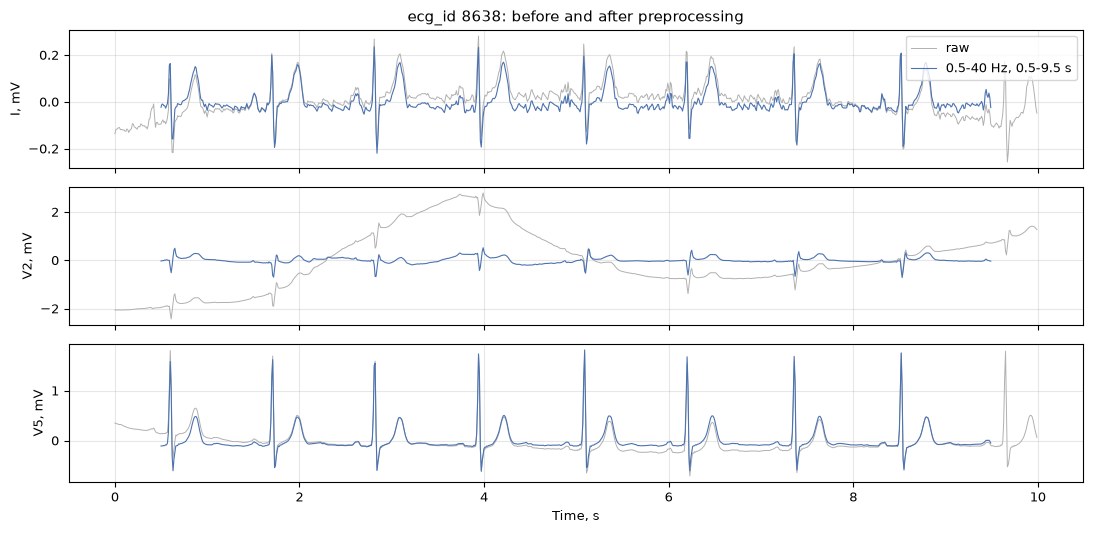

In [13]:
DRIFT_ID = 8638  # худшая запись по дрейфу из подвыборки недели 2
i = df.index.get_loc(DRIFT_ID)
t_raw, t_x = np.arange(N_SAMPLES) / FS, np.arange(CROP.start, CROP.stop) / FS
show = ['I', 'V2', 'V5']
fig, ax = plt.subplots(len(show), 1, figsize=(11, 5.4), sharex=True)
for a, lead in zip(ax, show):
    j = LEADS.index(lead)
    a.plot(t_raw, raw[i, :, j], lw=0.7, color='#B0B0B0', label='raw')
    a.plot(t_x, X[i, :, j], lw=0.8, color='#4C72B0', label='0.5-40 Hz, 0.5-9.5 s')
    a.set_ylabel(f'{lead}, mV')
ax[0].set_title(f'ecg_id {DRIFT_ID}: before and after preprocessing')
ax[0].legend(loc='upper right')
ax[-1].set_xlabel('Time, s')
plt.tight_layout()
plt.savefig(FIG_DIR + 'w3_before_after.png', dpi=150)
plt.show()

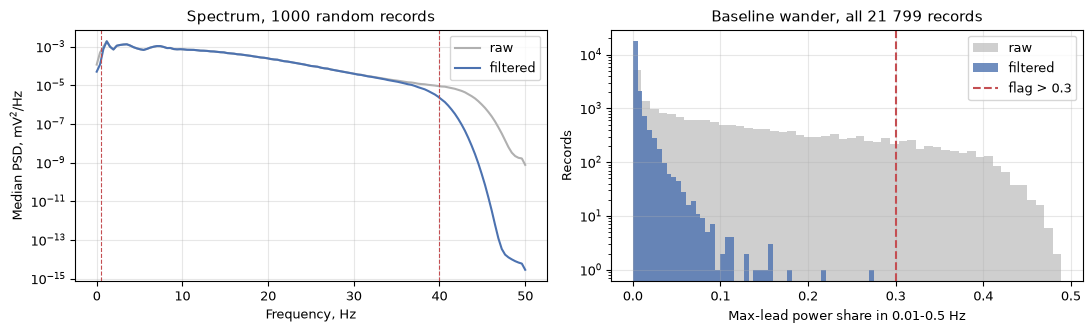

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
idx = np.random.default_rng(SEED).choice(len(X), 1000, replace=False)
f_r, p_r = welch(raw[idx][:, CROP], fs=FS, nperseg=256, axis=1)
f_x, p_x = welch(X[idx], fs=FS, nperseg=256, axis=1)
ax[0].semilogy(f_r, np.median(p_r, axis=(0, 2)), color='#B0B0B0', label='raw')
ax[0].semilogy(f_x, np.median(p_x, axis=(0, 2)), color='#4C72B0', label='filtered')
for b in BAND:
    ax[0].axvline(b, color='#C44E52', ls='--', lw=0.8)
ax[0].set(xlabel='Frequency, Hz', ylabel='Median PSD, mV$^2$/Hz', title='Spectrum, 1000 random records')
ax[0].legend()
ax[1].hist(before['drift'].max(1), bins=50, alpha=0.6, color='#B0B0B0', label='raw')
ax[1].hist(after['drift'].max(1), bins=50, alpha=0.8, color='#4C72B0', label='filtered')
ax[1].axvline(DRIFT_FLAG, color='#C44E52', ls='--', label=f'flag > {DRIFT_FLAG}')
ax[1].set(xlabel='Max-lead power share in 0.01-0.5 Hz', ylabel='Records', yscale='log',
          title='Baseline wander, all 21 799 records')
ax[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'w3_spectrum_drift.png', dpi=150)
plt.show()

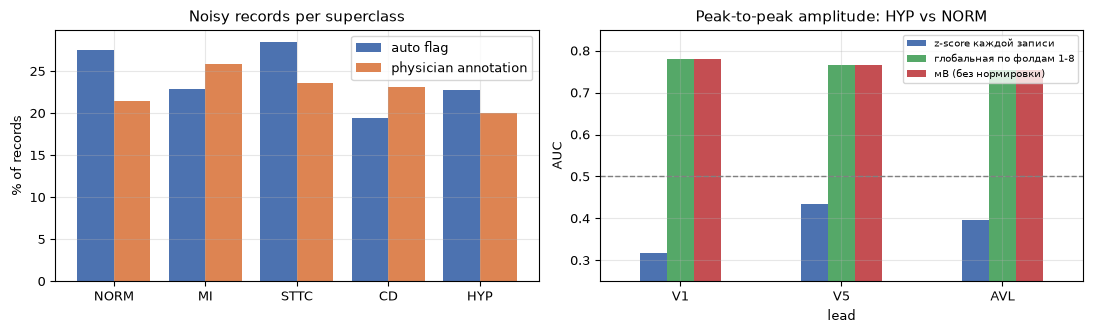

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
x = np.arange(len(SUPERCLASSES))
ax[0].bar(x - 0.2, flag_by_group.loc[SUPERCLASSES, 'flag_any_%'], 0.4, label='auto flag', color='#4C72B0')
ax[0].bar(x + 0.2, flag_by_group.loc[SUPERCLASSES, 'annotated_%'], 0.4, label='physician annotation', color='#DD8452')
ax[0].set_xticks(x, SUPERCLASSES)
ax[0].set(ylabel='% of records', title='Noisy records per superclass')
ax[0].legend()
amp_auc[['V1', 'V5', 'AVL']].T.plot.bar(ax=ax[1], color=['#4C72B0', '#55A868', '#C44E52'], rot=0)
ax[1].axhline(0.5, color='gray', ls='--', lw=1)
ax[1].set(ylim=(0.25, 0.85), ylabel='AUC', title='Peak-to-peak amplitude: HYP vs NORM')
ax[1].legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR + 'w3_groups_amplitude.png', dpi=150)
plt.show()

## Выводы недели 3

**Архитектуры.** Ориентир качества на задаче superdiagnostic — небольшая остаточная 1D-CNN `resnet1d_wang`
(macro-AUC 0.930, Strodthoff et al., 2021); LSTM близка (0.927). Transformer без предобучения на данных
масштаба PTB-XL CNN не превосходит, поэтому план на неделю 8 — гибрид «свёрточный стебель + attention».
Повторные запуски одной и той же сети разными авторами расходятся до 0.03 AUC, поэтому все модели года 2
сравниваются только внутри одного протокола.

**Контроль качества всего датасета.** Хотя бы один автоматический флаг — у 5 648 записей (25.9 %),
на подвыборке недели 2 было 25.2 %, то есть оценка по 500 записям была несмещённой. Метрика дрейфа надёжно
находит врачебную разметку `baseline_drift` (AUC 0.821). ВЧ-метрика с `static_noise` на полном датасете
связана статистически значимо (p = 3.9e-27), но слабо (AUC 0.559), с `burst_noise` не связана (AUC 0.519).
Вывод недели 2 сохраняется: на 100 Гц эти помехи почти не видны, учитывать их нужно по разметке датасета.

**Неожиданный результат — флаги качества зависят от пола.** На женских записях автоматический флаг
срабатывает чаще (29.3 % против 22.7 %), хотя врачебная разметка помех у полов одинакова (22.5 % и 23.4 %).
Гипотеза о меньшей амплитуде женских ЭКГ (медиана максимального размаха 2.34 против 2.80 мВ) **не
подтвердилась**: флаг дрейфа чаще у женщин в каждом терциле амплитуды. Причина пока не установлена. Для
диссертации это значит, что общие для обоих полов пороги контроля качества смещены; отбраковывать записи
по ним перед оценкой моделей по полу нельзя.

**Предобработка.** Фильтр 0.5–40 Гц снижает медианную долю мощности дрейфа с 7.4 % до 0.15 %, после него
флаг дрейфа не срабатывает ни на одной записи; доля мощности 40–49 Гц падает с 0.57 % до 0.05 %. Форма
сигнала сохраняется (корреляция 0.985), размах QRS — на 95–99 %. Все 21 799 записей обрабатываются за 5 с;
медленный этап — чтение файлов WFDB (~8 мин), поэтому результат кэширован.

**Нормировка.** Z-score каждой записи разрушает вольтажный признак гипертрофии: размах отведения V1
отделяет HYP от NORM с AUC 0.780 в мВ и лишь 0.316 после пер-записной нормировки (V5: 0.765 → 0.434,
aVL: 0.754 → 0.396). Выбрана нормировка по отведениям статистикой обучающих фолдов 1–8: она линейна,
амплитуду не трогает и не использует данные теста. На неделе 5 вывод проверяется на самой CNN (абляция).

## План на неделю 4

1. Многометочная матрица меток, исключение записей без диагноза.
2. Разбиение `strat_fold` 1–8 / 9 / 10 и проверка баланса классов, пола, возраста и качества.
3. Единый протокол оценки: macro-AUC с бутстреп-интервалами, анализ по полу, порог скрининга.
4. Классический baseline: признаки сигнала + XGBoost.